In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)

df = pd.read_csv(
    "European_Bank_Financial_Engagement_Analyzed.csv"
)

print("Dataset shape:", df.shape)

Dataset shape: (10000, 35)


In [2]:
df.head()

,Year,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Age_Group,Balance_Segment,Salary_Segment,Product_Depth_Group,Engagement_Status,Engagement_Profile,High_Value_Customer,High_Value_Disengaged,Customer_Value_Segment,Credit_Card_Status,Engagement_Score,Initial_Retention_Risk,Balance_to_Salary_Ratio,Financial_Segment,Churn_Status,Final_Engagement_Segment,Recommended_Strategy,Balance_Value_Group,Premium_Risk_Category,Premium_Risk_Score,Premium_Risk_Band
0,2025,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1,36-45,Low Balance,High Salary,Single Product,Active,Active Low-Product,0,0,Standard Value - Engaged,Card Holder,70,Low Risk,0.000000,High Salary - Low Balance,Churned,Engaged Growth,Cross-Sell Carefully,Standard Balance,Standard Customer,20,Low
1,2025,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0,36-45,Medium Balance,High Salary,Single Product,Active,Active Low-Product,0,0,Standard Value - Engaged,Non Card Holder,50,Low Risk,0.744677,High Salary - Low Balance,Retained,Engaged Growth,Cross-Sell Carefully,Standard Balance,Standard Customer,30,Low
2,2025,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1,36-45,Very High Balance,High Salary,3+ Products,Inactive,Inactive Multi-Product,1,1,High Value - Disengaged,Card Holder,50,High Risk,1.401375,High Salary - High Balance,Churned,Complex / Investigate,Investigate Product-Churn Pattern,High Balance,High Premium Risk,70,High
3,2025,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0,36-45,Low Balance,Medium Salary,Two Products,Inactive,Inactive Multi-Product,0,0,Standard Value - Disengaged,Non Card Holder,30,Medium Risk,0.000000,Low Salary - Low Balance,Retained,Dormant Relationship,Reactivate,Standard Balance,Standard Customer,40,Medium
4,2025,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0,36-45,High Balance,Medium Salary,Single Product,Active,Active Low-Product,0,0,Standard Value - Engaged,Card Holder,70,Low Risk,1.587055,Low Salary - High Balance,Retained,Engaged Growth,Cross-Sell Carefully,Standard Balance,Standard Customer,20,Low


In [3]:
required_columns = [
    "CustomerId",
    "CreditScore",
    "Age",
    "Balance",
    "NumOfProducts",
    "HasCrCard",
    "IsActiveMember",
    "EstimatedSalary",
    "Exited",
    "Engagement_Status",
    "Final_Engagement_Segment",
    "High_Value_Customer",
    "High_Value_Disengaged",
    "Premium_Risk_Score",
    "Premium_Risk_Band"
]

missing_required = [
    col for col in required_columns
    if col not in df.columns
]

print("Missing required columns:", missing_required)

Missing required columns: []


In [4]:
df["Engagement_Component"] = np.where(
    df["IsActiveMember"] == 1,
    40,
    0
)

In [5]:
def product_depth_score(products):
    
    if products == 1:
        return 10
    elif products == 2:
        return 30
    elif products == 3:
        return 20
    else:
        return 15

df["Product_Depth_Component"] = (
    df["NumOfProducts"]
    .apply(product_depth_score)
)

In [6]:
df["Credit_Card_Component"] = np.where(
    df["HasCrCard"] == 1,
    15,
    0
)

In [7]:
df["Financial_Component"] = np.where(
    df["High_Value_Customer"] == 1,
    15,
    5
)

In [8]:
df["Relationship_Strength_Index"] = (
    df["Engagement_Component"]
    + df["Product_Depth_Component"]
    + df["Credit_Card_Component"]
    + df["Financial_Component"]
)

In [9]:
df["Relationship_Strength_Index"].describe()

count    10000.000000
mean        58.162500
std         23.508006
min         15.000000
25%         35.000000
50%         55.000000
75%         75.000000
max        100.000000
Name: Relationship_Strength_Index, dtype: float64

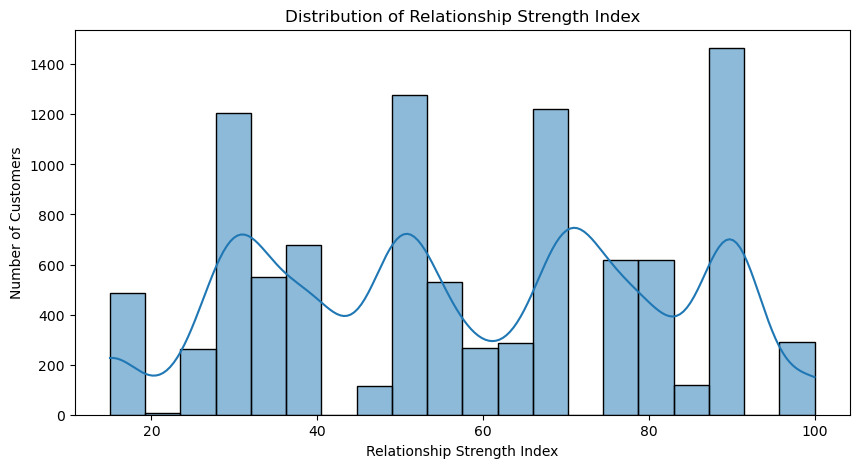

In [10]:
plt.figure(figsize=(10, 5))

sns.histplot(
    data=df,
    x="Relationship_Strength_Index",
    bins=20,
    kde=True
)

plt.title("Distribution of Relationship Strength Index")
plt.xlabel("Relationship Strength Index")
plt.ylabel("Number of Customers")

plt.show()

In [11]:
def relationship_band(score):
    
    if score >= 75:
        return "Strong"
    
    elif score >= 50:
        return "Moderate"
    
    elif score >= 25:
        return "Weak"
    
    else:
        return "Very Weak"

df["Relationship_Strength_Band"] = (
    df["Relationship_Strength_Index"]
    .apply(relationship_band)
)

In [12]:
df["Relationship_Strength_Band"].value_counts()

Relationship_Strength_Band
Moderate     3586
Strong       3107
Weak         2812
Very Weak     495
Name: count, dtype: int64

In [13]:
rsi_analysis = (
    df.groupby("Relationship_Strength_Band")
    .agg(
        Customers=("CustomerId", "count"),
        Churned=("Exited", "sum"),
        Churn_Rate=("Exited", "mean"),
        Avg_RSI=("Relationship_Strength_Index", "mean"),
        Avg_Balance=("Balance", "mean"),
        Avg_Products=("NumOfProducts", "mean"),
        Active_Rate=("IsActiveMember", "mean")
    )
    .reset_index()
)

rsi_analysis["Churn_Rate"] *= 100
rsi_analysis["Active_Rate"] *= 100

rsi_analysis

,Relationship_Strength_Band,Customers,Churned,Churn_Rate,Avg_RSI,Avg_Balance,Avg_Products,Active_Rate
0,Moderate,3586,598,16.675962,59.498048,71351.635022,1.463748,56.999442
1,Strong,3107,314,10.106212,85.775668,70108.022559,1.859028,100.000000
2,Very Weak,495,185,37.373737,15.070707,77405.361515,1.042424,0.000000
3,Weak,2812,940,33.428165,33.534851,89918.438709,1.337482,0.000000


In [14]:
band_order = [
    "Very Weak",
    "Weak",
    "Moderate",
    "Strong"
]

rsi_analysis["Relationship_Strength_Band"] = pd.Categorical(
    rsi_analysis["Relationship_Strength_Band"],
    categories=band_order,
    ordered=True
)

rsi_analysis = (
    rsi_analysis
    .sort_values("Relationship_Strength_Band")
)

rsi_analysis.round(2)

,Relationship_Strength_Band,Customers,Churned,Churn_Rate,Avg_RSI,Avg_Balance,Avg_Products,Active_Rate
2,Very Weak,495,185,37.37,15.07,77405.36,1.04,0.0
3,Weak,2812,940,33.43,33.53,89918.44,1.34,0.0
0,Moderate,3586,598,16.68,59.50,71351.64,1.46,57.0
1,Strong,3107,314,10.11,85.78,70108.02,1.86,100.0


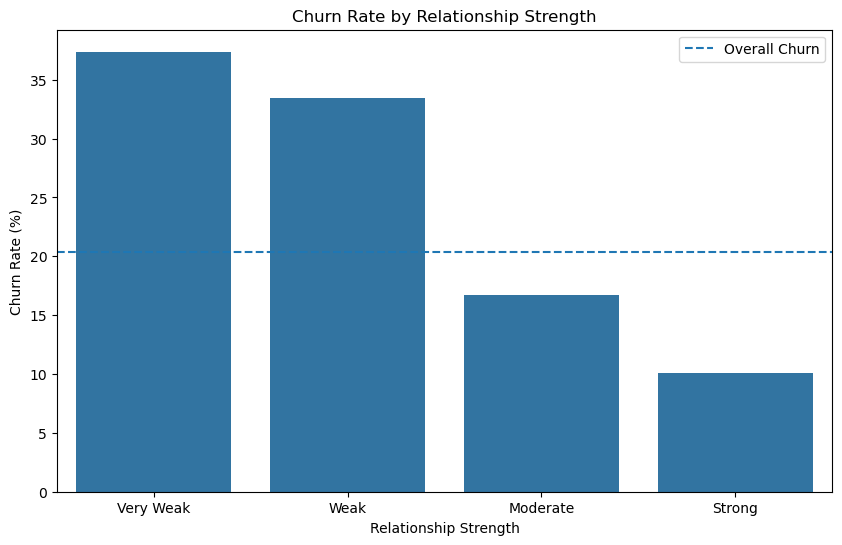

In [15]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=rsi_analysis,
    x="Relationship_Strength_Band",
    y="Churn_Rate",
    order=band_order
)

plt.axhline(
    df["Exited"].mean() * 100,
    linestyle="--",
    label="Overall Churn"
)

plt.title(
    "Churn Rate by Relationship Strength"
)

plt.xlabel("Relationship Strength")
plt.ylabel("Churn Rate (%)")
plt.legend()

plt.show()

In [16]:
rsi_exact = (
    df.groupby("Relationship_Strength_Index")
    .agg(
        Customers=("CustomerId", "count"),
        Churn_Rate=("Exited", "mean")
    )
    .reset_index()
)

rsi_exact["Churn_Rate"] *= 100

rsi_exact.head()

,Relationship_Strength_Index,Customers,Churn_Rate
0,15,488,36.475410
1,20,7,100.000000
2,25,261,37.164751
3,30,1207,39.022370
4,35,552,13.043478


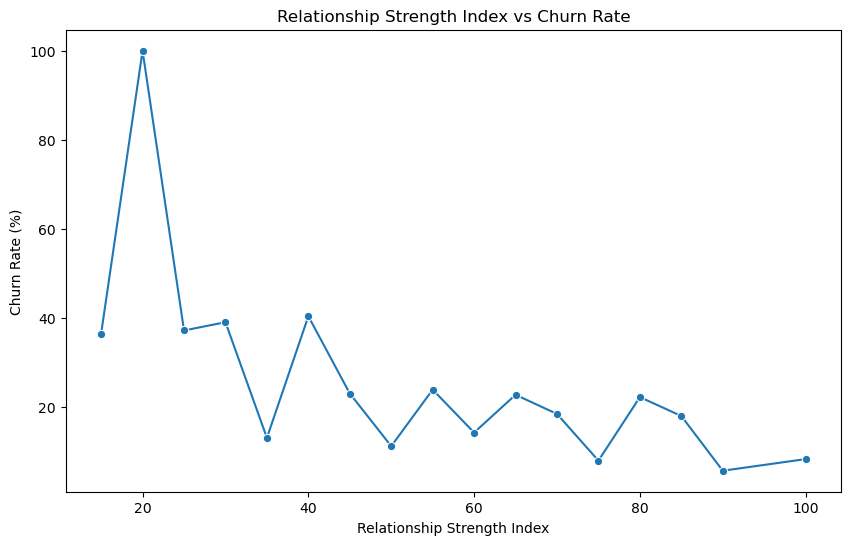

In [17]:
plt.figure(figsize=(10, 6))

sns.lineplot(
    data=rsi_exact,
    x="Relationship_Strength_Index",
    y="Churn_Rate",
    marker="o"
)

plt.title(
    "Relationship Strength Index vs Churn Rate"
)

plt.xlabel("Relationship Strength Index")
plt.ylabel("Churn Rate (%)")

plt.show()

In [18]:
df["RSI_Percentile"] = (
    df["Relationship_Strength_Index"]
    .rank(pct=True)
    * 100
)

In [19]:
df["Retention_Risk_Score"] = (
    100 - df["Relationship_Strength_Index"]
)

In [20]:
df["Retention_Risk_Score"].describe()

count    10000.000000
mean        41.837500
std         23.508006
min          0.000000
25%         25.000000
50%         45.000000
75%         65.000000
max         85.000000
Name: Retention_Risk_Score, dtype: float64

In [21]:
df["Retention_Risk_Score_Adjusted"] = (
    df["Retention_Risk_Score"]
    + np.where(
        df["High_Value_Disengaged"] == 1,
        10,
        0
    )
)

In [22]:
df["Retention_Risk_Score_Adjusted"] = (
    df["Retention_Risk_Score_Adjusted"]
    .clip(upper=100)
)

In [23]:
def retention_risk_band(score):
    
    if score >= 75:
        return "Critical Risk"
    
    elif score >= 50:
        return "High Risk"
    
    elif score >= 25:
        return "Medium Risk"
    
    else:
        return "Low Risk"

df["Retention_Risk_Band"] = (
    df["Retention_Risk_Score_Adjusted"]
    .apply(retention_risk_band)
)

In [24]:
df["Retention_Risk_Band"].value_counts()

Retention_Risk_Band
High Risk        4081
Medium Risk      2662
Low Risk         2489
Critical Risk     768
Name: count, dtype: int64

In [25]:
risk_analysis = (
    df.groupby("Retention_Risk_Band")
    .agg(
        Customers=("CustomerId", "count"),
        Churned=("Exited", "sum"),
        Actual_Churn_Rate=("Exited", "mean"),
        Avg_RSI=("Relationship_Strength_Index", "mean"),
        Avg_Balance=("Balance", "mean"),
        Avg_Products=("NumOfProducts", "mean"),
        Active_Rate=("IsActiveMember", "mean")
    )
    .reset_index()
)

risk_analysis["Actual_Churn_Rate"] *= 100
risk_analysis["Active_Rate"] *= 100

risk_analysis

,Retention_Risk_Band,Customers,Churned,Actual_Churn_Rate,Avg_RSI,Avg_Balance,Avg_Products,Active_Rate
0,Critical Risk,768,294,38.281250,18.743490,98945.880065,1.141927,0.0
1,High Risk,4081,1008,24.699828,40.944621,73029.688194,1.596422,0.0
2,Low Risk,2489,265,10.646846,88.451185,78393.278795,1.811571,100.0
3,Medium Risk,2662,470,17.655898,67.610819,73521.197802,1.277611,100.0


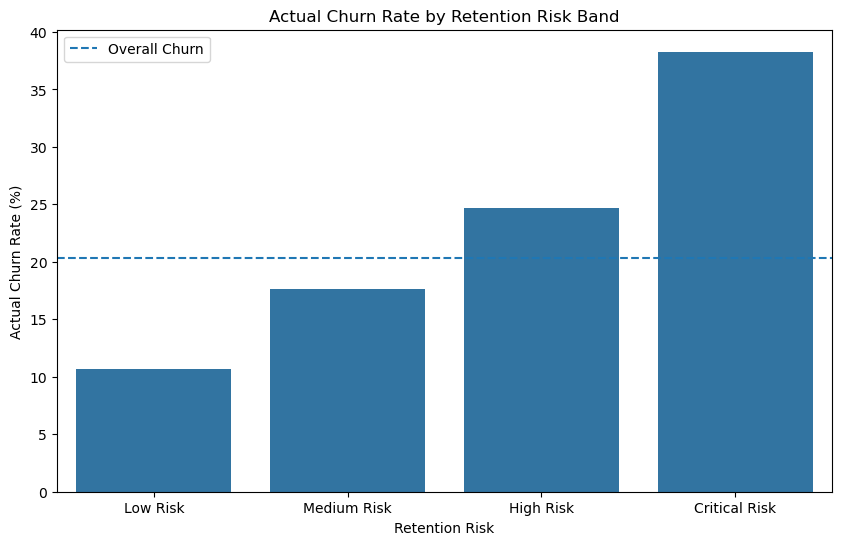

In [26]:
risk_order = [
    "Low Risk",
    "Medium Risk",
    "High Risk",
    "Critical Risk"
]

plt.figure(figsize=(10, 6))

sns.barplot(
    data=risk_analysis,
    x="Retention_Risk_Band",
    y="Actual_Churn_Rate",
    order=risk_order
)

plt.axhline(
    df["Exited"].mean() * 100,
    linestyle="--",
    label="Overall Churn"
)

plt.title(
    "Actual Churn Rate by Retention Risk Band"
)

plt.xlabel("Retention Risk")
plt.ylabel("Actual Churn Rate (%)")
plt.legend()

plt.show()

In [27]:
critical_customers = df[
    df["Retention_Risk_Band"] == "Critical Risk"
].copy()

In [28]:
critical_columns = [
    "CustomerId",
    "Geography",
    "Age",
    "Balance",
    "EstimatedSalary",
    "NumOfProducts",
    "HasCrCard",
    "IsActiveMember",
    "Relationship_Strength_Index",
    "Relationship_Strength_Band",
    "Retention_Risk_Score_Adjusted",
    "Retention_Risk_Band",
    "Exited"
]

critical_customers[
    critical_columns
].sort_values(
    "Retention_Risk_Score_Adjusted",
    ascending=False
).head(25)

,CustomerId,Geography,Age,Balance,EstimatedSalary,NumOfProducts,HasCrCard,IsActiveMember,Relationship_Strength_Index,Relationship_Strength_Band,Retention_Risk_Score_Adjusted,Retention_Risk_Band,Exited
18,15661507,Spain,45,0.00,158684.81,1,0,0,15,Very Weak,85,Critical Risk,0
6698,15784491,France,31,0.00,61326.43,1,0,0,15,Very Weak,85,Critical Risk,0
6574,15661290,Germany,38,107199.75,146398.51,1,0,0,15,Very Weak,85,Critical Risk,0
6594,15808544,France,40,0.00,57817.84,1,0,0,15,Very Weak,85,Critical Risk,1
6597,15637774,France,32,73494.21,136301.10,1,0,0,15,Very Weak,85,Critical Risk,0
6651,15803941,France,46,95502.21,19842.18,1,0,0,15,Very Weak,85,Critical Risk,0
6654,15799998,France,30,85859.76,142730.27,1,0,0,15,Very Weak,85,Critical Risk,0
6658,15777873,France,31,0.00,147963.07,1,0,0,15,Very Weak,85,Critical Risk,1
6669,15797900,France,56,142147.32,39488.04,1,0,0,25,Weak,85,Critical Risk,1
6673,15736299,France,36,109106.80,121311.12,1,0,0,15,Very Weak,85,Critical Risk,0


In [29]:
risk_profile_analysis = (
    df.groupby(
        ["Final_Engagement_Segment", "Retention_Risk_Band"]
    )
    .agg(
        Customers=("CustomerId", "count"),
        Churn_Rate=("Exited", "mean")
    )
    .reset_index()
)

risk_profile_analysis["Churn_Rate"] *= 100

risk_profile_analysis.round(2)

,Final_Engagement_Segment,Retention_Risk_Band,Customers,Churn_Rate
0,Complex / Investigate,Critical Risk,50,92.00
1,Complex / Investigate,High Risk,134,89.55
2,Complex / Investigate,Low Risk,84,76.19
3,Complex / Investigate,Medium Risk,58,86.21
4,Disengaged Single-Product,Critical Risk,718,34.54
5,Disengaged Single-Product,High Risk,1803,37.49
6,Dormant Relationship,High Risk,2144,9.89
7,Engaged Growth,Low Risk,559,17.17
8,Engaged Growth,Medium Risk,2004,19.41
9,Highly Engaged,Low Risk,1846,5.69


In [30]:
value_rsi = (
    df.groupby("Customer_Value_Segment")
    .agg(
        Customers=("CustomerId", "count"),
        Avg_RSI=("Relationship_Strength_Index", "mean"),
        Avg_Risk=("Retention_Risk_Score_Adjusted", "mean"),
        Churn_Rate=("Exited", "mean")
    )
    .reset_index()
)

value_rsi["Churn_Rate"] *= 100

value_rsi.round(2)

,Customer_Value_Segment,Customers,Avg_RSI,Avg_Risk,Churn_Rate
0,High Value - Disengaged,1247,42.10,67.90,30.47
1,High Value - Engaged,1253,82.12,17.88,16.92
2,Standard Value - Disengaged,3602,35.81,64.19,25.60
3,Standard Value - Engaged,3898,76.25,23.75,13.42


In [31]:
def relationship_classification(row):
    
    if (
        row["Relationship_Strength_Band"] == "Strong"
        and row["Retention_Risk_Band"] == "Low Risk"
    ):
        return "Strong Relationship"
    
    elif (
        row["IsActiveMember"] == 1
        and row["NumOfProducts"] == 1
    ):
        return "Growth Opportunity"
    
    elif (
        row["High_Value_Disengaged"] == 1
    ):
        return "At-Risk Premium"
    
    elif (
        row["IsActiveMember"] == 0
    ):
        return "Disengaged"
    
    else:
        return "Developing Relationship"

df["Relationship_Classification"] = df.apply(
    relationship_classification,
    axis=1
)

In [32]:
df["Relationship_Classification"].value_counts()

Relationship_Classification
Disengaged                 3602
Strong Relationship        2489
Growth Opportunity         2004
At-Risk Premium            1247
Developing Relationship     658
Name: count, dtype: int64

In [33]:
retention_strategy = {
    "Strong Relationship":
        "Retain, reward, and strengthen loyalty",
    
    "Growth Opportunity":
        "Targeted cross-sell based on customer needs",
    
    "At-Risk Premium":
        "Priority proactive retention and relationship outreach",
    
    "Disengaged":
        "Reactivation and engagement campaign",
    
    "Developing Relationship":
        "Increase product adoption and engagement"
}

df["Retention_Strategy"] = (
    df["Relationship_Classification"]
    .map(retention_strategy)
)

In [34]:
df[
    [
        "Relationship_Classification",
        "Retention_Strategy"
    ]
].drop_duplicates()

,Relationship_Classification,Retention_Strategy
0,Growth Opportunity,Targeted cross-sell based on customer needs
2,At-Risk Premium,Priority proactive retention and relationship ...
3,Disengaged,Reactivation and engagement campaign
6,Strong Relationship,"Retain, reward, and strengthen loyalty"
23,Developing Relationship,Increase product adoption and engagement


In [35]:
executive_scoring_table = (
    df.groupby("Relationship_Classification")
    .agg(
        Customers=("CustomerId", "count"),
        Churned=("Exited", "sum"),
        Churn_Rate=("Exited", "mean"),
        Avg_RSI=("Relationship_Strength_Index", "mean"),
        Avg_Risk_Score=("Retention_Risk_Score_Adjusted", "mean"),
        Avg_Balance=("Balance", "mean"),
        Avg_Products=("NumOfProducts", "mean")
    )
    .reset_index()
)

executive_scoring_table["Churn_Rate"] *= 100

executive_scoring_table.round(2)

,Relationship_Classification,Customers,Churned,Churn_Rate,Avg_RSI,Avg_Risk_Score,Avg_Balance,Avg_Products
0,At-Risk Premium,1247,380,30.47,42.10,67.90,148857.68,1.38
1,Developing Relationship,658,81,12.31,74.41,25.59,38341.20,2.12
2,Disengaged,3602,922,25.60,35.81,64.19,52304.02,1.57
3,Growth Opportunity,2004,389,19.41,65.38,34.62,85072.32,1.00
4,Strong Relationship,2489,265,10.65,88.45,11.55,78393.28,1.81


In [36]:
score_validation = (
    df.groupby("Relationship_Strength_Band")
    .agg(
        Customers=("CustomerId", "count"),
        Actual_Churn=("Exited", "mean"),
        Average_RSI=("Relationship_Strength_Index", "mean"),
        Average_Risk=("Retention_Risk_Score_Adjusted", "mean")
    )
    .reset_index()
)

score_validation["Actual_Churn"] *= 100

score_validation

,Relationship_Strength_Band,Customers,Actual_Churn,Average_RSI,Average_Risk
0,Moderate,3586,16.675962,59.498048,41.321807
1,Strong,3107,10.106212,85.775668,14.224332
2,Very Weak,495,37.373737,15.070707,84.929293
3,Weak,2812,33.428165,33.534851,69.854196


In [37]:
final_scorecard = df[
    [
        "CustomerId",
        "Geography",
        "Age",
        "Balance",
        "EstimatedSalary",
        "NumOfProducts",
        "HasCrCard",
        "IsActiveMember",
        "Exited",
        "Final_Engagement_Segment",
        "High_Value_Disengaged",
        "Relationship_Strength_Index",
        "Relationship_Strength_Band",
        "Retention_Risk_Score_Adjusted",
        "Retention_Risk_Band",
        "Relationship_Classification",
        "Retention_Strategy"
    ]
].copy()

In [38]:
final_scorecard = final_scorecard.sort_values(
    "Retention_Risk_Score_Adjusted",
    ascending=False
)

final_scorecard.head(20)

,CustomerId,Geography,Age,Balance,EstimatedSalary,NumOfProducts,HasCrCard,IsActiveMember,Exited,Final_Engagement_Segment,High_Value_Disengaged,Relationship_Strength_Index,Relationship_Strength_Band,Retention_Risk_Score_Adjusted,Retention_Risk_Band,Relationship_Classification,Retention_Strategy
8196,15589312,France,30,115007.08,176858.50,1,0,0,0,Disengaged Single-Product,0,15,Very Weak,85,Critical Risk,Disengaged,Reactivation and engagement campaign
4312,15720687,France,41,112609.91,191035.18,1,0,0,1,Disengaged Single-Product,0,15,Very Weak,85,Critical Risk,Disengaged,Reactivation and engagement campaign
710,15722548,France,48,148116.48,116973.48,1,0,0,0,Disengaged Single-Product,1,25,Weak,85,Critical Risk,At-Risk Premium,Priority proactive retention and relationship ...
9026,15807593,Spain,36,85660.96,134778.01,1,0,0,0,Disengaged Single-Product,0,15,Very Weak,85,Critical Risk,Disengaged,Reactivation and engagement campaign
7077,15725776,Germany,24,101195.23,133091.32,1,0,0,0,Disengaged Single-Product,0,15,Very Weak,85,Critical Risk,Disengaged,Reactivation and engagement campaign
716,15677369,Germany,37,58629.97,182038.60,1,0,0,0,Disengaged Single-Product,0,15,Very Weak,85,Critical Risk,Disengaged,Reactivation and engagement campaign
2910,15746139,France,33,139451.67,63142.12,1,0,0,0,Disengaged Single-Product,1,25,Weak,85,Critical Risk,At-Risk Premium,Priority proactive retention and relationship ...
4559,15668248,Germany,62,133201.17,168507.68,1,0,0,1,Disengaged Single-Product,1,25,Weak,85,Critical Risk,At-Risk Premium,Priority proactive retention and relationship ...
2919,15736760,Spain,42,0.00,152855.96,1,0,0,0,Disengaged Single-Product,0,15,Very Weak,85,Critical Risk,Disengaged,Reactivation and engagement campaign
8098,15594391,France,68,183555.24,159557.28,1,0,0,1,Disengaged Single-Product,1,25,Weak,85,Critical Risk,At-Risk Premium,Priority proactive retention and relationship ...


In [39]:
df.to_csv(
    "European_Bank_Retention_Scored.csv",
    index=False
)

print(
    "✅ Retention-scored dataset saved successfully."
)

✅ Retention-scored dataset saved successfully.


In [40]:
rsi_analysis.to_csv(
    "Relationship_Strength_Analysis.csv",
    index=False
)

risk_analysis.to_csv(
    "Retention_Risk_Analysis.csv",
    index=False
)

executive_scoring_table.to_csv(
    "Executive_Retention_Summary.csv",
    index=False
)

final_scorecard.to_csv(
    "Customer_Retention_Scorecard.csv",
    index=False
)